In [48]:
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import talib as ta
from scipy.stats import norm

In [170]:
end_date = datetime.today()
start_date = end_date - timedelta(days=365)

In [181]:
# ticker = '^NSEI'
# ticker = "GC=F"
ticker = "SI=F"

In [182]:
data = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [183]:
vwap = ta.VWAP(data['High'], data['Low'], data['Close'], data['Volume'])

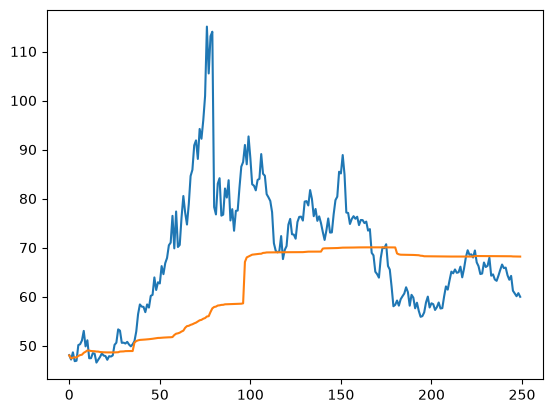

In [184]:
plt.plot(data['Close'].values)
plt.plot(vwap.values)
plt.show()

In [185]:
close_prices = data['Close']
vwap_prices = vwap

In [186]:
log_deviations = np.log(close_prices / vwap_prices).values

mean = np.mean(log_deviations)
std = np.std(log_deviations)

In [187]:
obv = ta.OBV(data['Close'], data['Volume']).values

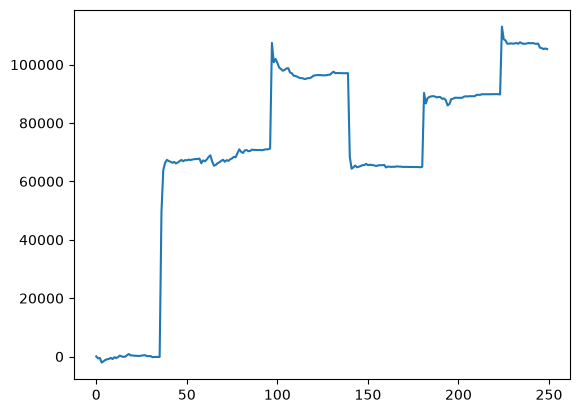

In [188]:
plt.plot(obv)

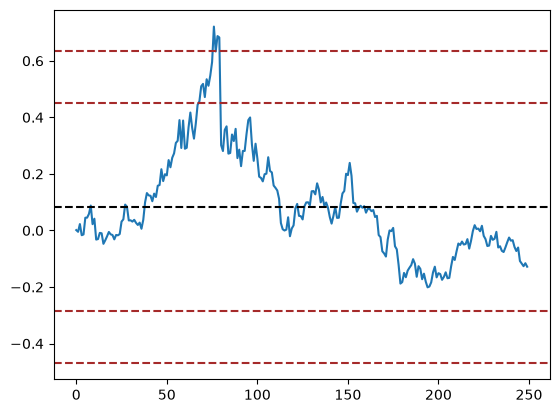

In [189]:
plt.plot(log_deviations)

plt.axhline(y=mean + 3 * std, color='brown', linestyle='--')
plt.axhline(y=mean + 2 * std, color='brown', linestyle='--')
plt.axhline(y=mean, color='black', linestyle='--')
plt.axhline(y=mean - 2 * std, color='brown', linestyle='--')
plt.axhline(y=mean - 3 * std, color='brown', linestyle='--')

plt.show()